# RNN으로_금융앱리뷰_분석하기

In [1]:
# !pip install konlpy
# !pip install mecab-python3

In [3]:
from konlpy.tag import Mecab
import pandas as pd
import numpy as np
from tensorflow.keras.preprocessing.text import Tokenizer, text_to_word_sequence
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Embedding
from tensorflow.keras.utils import to_categorical

In [4]:
train_data = pd.read_csv("./data/bank_app_reviews_train.csv")
train_data.head()

,리뷰일,평점,사용자리뷰,업체답변,은행명
0,2023-12-21,5,엄빠 폰에 설치해드렸는데 두분 다 쓰기 편하다고 하시네요 ㅎㅎ 저도 쓰고있음!,NaN,하나
1,2025-02-17,1,Cd기 축소 연장하려면 이 어플 깔라는데 왜 30퍼에서 안깔리는지 아니 애초에 슈퍼...,안녕하세요. 신한은행입니다.\n먼저 SOL사용에 불편을 드려 죄송합니다.\n어플의 ...,신한
2,2024-07-26,5,서비스가 통합되어 있어서 점점 사용빈도가 높아지네요.,고객님 안녕하세요! KB스타뱅킹을 이용해 주셔서 진심으로 감사드립니다. KB스타뱅킹...,국민
3,2024-09-01,1,카드 충천이 안됌,"안녕하세요. 전민구 님, 토스팀입니다. 남겨주신 내용만으로는 겪고계신 불편사항의 자...",토스
4,2023-11-13,1,알뜰폰 인증이 안돼요.....,"안녕하세요 헤이모두들안녕님, 우리은행입니다. 먼저 이용에 불편을 드려 매우 죄송합니...",우리


특수문자 제거 함수

In [6]:
import re

def clean_text(text):
    cleaned = re.sub(r'[^가-힣a-zA-Z0-9\s]','', text) #한글, 영문, 숫자
    cleaned = re.sub(r'\s+', ' ', cleaned) # 연속된 공백을 하나의 공백
    return cleaned.strip()

사용자 리뷰에서 특수문자 제거

In [7]:
train_data['사용자리뷰'] = train_data['사용자리뷰'].apply(clean_text)
train_data['사용자리뷰']

0                  엄빠 폰에 설치해드렸는데 두분 다 쓰기 편하다고 하시네요 저도 쓰고있음
1        Cd기 축소 연장하려면 이 어플 깔라는데 왜 30퍼에서 안깔리는지 아니 애초에 슈퍼...
2                             서비스가 통합되어 있어서 점점 사용빈도가 높아지네요
3                                                카드 충천이 안됌
4                                              알뜰폰 인증이 안돼요
                               ...                        
22241                                      어플 시작오류가 가끔 나네요
22242                              업데이트 후에 계좌이체하는 게 자주 튕겨요
22243                                                  굳굳굳
22244                                  오래시간 같이한 나의은행 든든합니다
22245    라이브 광고 전보다 더 안좋네 아무리 주기 싫어도 겨우 3원줄거면서 너무 쪼잔하게 ...
Name: 사용자리뷰, Length: 22246, dtype: object

is_good 컬럼 추가, 평점 4이상은 긍정: 1, 3이하는 부정: 0

In [8]:
train_data['is_good'] = train_data['평점'].apply(lambda x: 1 if x >=4 else 0)
train_data['is_good']

0        1
1        0
2        1
3        0
4        0
        ..
22241    0
22242    0
22243    1
22244    1
22245    0
Name: is_good, Length: 22246, dtype: int64

토큰화

In [9]:
train_data['사용자리뷰']

0                  엄빠 폰에 설치해드렸는데 두분 다 쓰기 편하다고 하시네요 저도 쓰고있음
1        Cd기 축소 연장하려면 이 어플 깔라는데 왜 30퍼에서 안깔리는지 아니 애초에 슈퍼...
2                             서비스가 통합되어 있어서 점점 사용빈도가 높아지네요
3                                                카드 충천이 안됌
4                                              알뜰폰 인증이 안돼요
                               ...                        
22241                                      어플 시작오류가 가끔 나네요
22242                              업데이트 후에 계좌이체하는 게 자주 튕겨요
22243                                                  굳굳굳
22244                                  오래시간 같이한 나의은행 든든합니다
22245    라이브 광고 전보다 더 안좋네 아무리 주기 싫어도 겨우 3원줄거면서 너무 쪼잔하게 ...
Name: 사용자리뷰, Length: 22246, dtype: object

In [10]:
mecab = Mecab()
mecab.morphs(train_data['사용자리뷰'][0])

['엄',
 '빠',
 '폰',
 '에',
 '설치',
 '해',
 '드렸',
 '는데',
 '두',
 '분',
 '다',
 '쓰',
 '기',
 '편하',
 '다고',
 '하',
 '시',
 '네요',
 '저',
 '도',
 '쓰',
 '고',
 '있',
 '음']

전체 문장을 토큰화 한 후 tokenized_docs에 저장

In [11]:
tokenized_docs = train_data['사용자리뷰'].apply(mecab.morphs)

In [12]:
tokenized_docs[2]

['서비스',
 '가',
 '통합',
 '되',
 '어',
 '있',
 '어서',
 '점점',
 '사용',
 '빈도',
 '가',
 '높',
 '아',
 '지',
 '네요']

단어 인덱스 생성

In [13]:
token = Tokenizer(lower=False)
token.fit_on_texts(tokenized_docs)
print(len(token.word_index))

13010


문장 벡터화

In [14]:
x = token.texts_to_sequences(tokenized_docs)
print(x[0])

[5400, 1682, 170, 11, 159, 37, 2292, 14, 301, 184, 28, 45, 19, 106, 123, 1, 76, 15, 216, 5, 45, 2, 10, 64]


가장 긴 문장의 길이 구하기

In [15]:
max_length = max([len(i) for i in x]) + 1
max_length

302

가장 긴 길이에 맞춰서 패딩
* RNN의 경우 패딩을 post로 주는 것이 더 좋음, 단어가 앞, 0이 뒤에 붙음
* Transformer계열은 위치 정보가 따로 있으므로 post, pre든 차이가 없음

In [16]:
X_padded = pad_sequences(x, maxlen=max_length, padding='post')
print(X_padded[1])

[7174   19 2404 1948    1  414    3   18   52  210 1258   51  521 1604
   42    6 3601  143   90 1518   11  725  553 1003  114    3   18   52
  435    2  725  923   11   94  221   18   29  485   51 4003 4523 4004
   58  277   77  725  923  923  251   28  210   13  366    4   39  250
 2830  332    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0 

In [17]:
X_padded.shape

(22246, 302)

In [18]:
y = train_data['is_good']
y.value_counts()

is_good
1    13240
0     9006
Name: count, dtype: int64

홀드아웃

In [29]:
# !pip install scikit-learn

In [20]:
from sklearn.model_selection import train_test_split

In [21]:
X_train, X_valid, y_train, y_valid = train_test_split(X_padded, y, test_size=0.3, stratify=y, random_state=42)

In [22]:
# 임베딩에 입력할 단어 수 추출
word_size = len(token.word_index)
print(word_size)

13010


In [23]:
import joblib

In [24]:
joblib.dump(token, "./model/bank_app_tokeizer.joblib")
joblib.dump(max_length, "./model/bank_app_max_length.joblib")

['./model/bank_app_max_length.joblib']

# 양방향 RNN 네트워크를 이용해 텍스트 분석

In [33]:
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.layers import Input, Embedding, SimpleRNN, Dense, Dropout, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

In [34]:
birnn = Sequential()
birnn.add(Input(shape=(max_length,)))
birnn.add(Embedding(input_dim=word_size, output_dim=64))
birnn.add(Bidirectional(SimpleRNN(128, return_sequences=False, activation='tanh')))
birnn.add(Dense(32, activation='relu'))
birnn.add(Dropout(0.5))
birnn.add(Dense(1, activation='sigmoid'))
birnn.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 302, 64)        │       832,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 256)            │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         8,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 890,305 (3.40 MB)

 Trainable params: 890,305 (3.40 MB)

 Non-trainable params: 0 (0.00 B)

In [35]:
birnn.compile(loss='binary_crossentropy', optimizer='adam',
             metrics=['accuracy', tf.keras.metrics.AUC(name='auc')])
early_stop = EarlyStopping(patience=10, restore_best_weights=True)
model_path = "./model/bank_app_review_birnn.keras"
checkpoint = ModelCheckpoint(filepath=model_path, monitor='val_loss',
                            save_best_only=True,
                            verbose=1)
birnn_history = birnn.fit(X_train, y_train, epochs=1000, batch_size=64,
                         validation_data=(X_valid, y_valid),
                         callbacks=[early_stop, checkpoint])

Epoch 1/1000
204/244 ━━━━━━━━━━━━━━━━━━━━ 5s 135ms/step - accuracy: 0.7579 - auc: 0.8137 - loss: 0.5037

2025-05-23 09:31:05.194046: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: INVALID_ARGUMENT: indices[36,27] = 13010 is not in [0, 13010)
	 [[{{function_node __inference_one_step_on_data_12058}}{{node sequential_1_1/embedding_1_1/GatherV2}}]]


InvalidArgumentError: Graph execution error:

Detected at node sequential_1_1/embedding_1_1/GatherV2 defined at (most recent call last):
  File "/home/fintech/miniforge3/envs/face/lib/python3.10/runpy.py", line 196, in _run_module_as_main

  File "/home/fintech/miniforge3/envs/face/lib/python3.10/runpy.py", line 86, in _run_code

  File "/home/fintech/miniforge3/envs/face/lib/python3.10/site-packages/ipykernel_launcher.py", line 18, in <module>

  File "/home/fintech/miniforge3/envs/face/lib/python3.10/site-packages/traitlets/config/application.py", line 1075, in launch_instance

  File "/home/fintech/miniforge3/envs/face/lib/python3.10/site-packages/ipykernel/kernelapp.py", line 739, in start

  File "/home/fintech/miniforge3/envs/face/lib/python3.10/site-packages/tornado/platform/asyncio.py", line 211, in start

  File "/home/fintech/miniforge3/envs/face/lib/python3.10/asyncio/base_events.py", line 603, in run_forever

  File "/home/fintech/miniforge3/envs/face/lib/python3.10/asyncio

In [30]:
plt.figure(figsize=(8, 5))
plt.plot(birnn_history.history['loss'])
plt.plot(birnn_history.history['val_loss'])
plt.xlabel('epochs')
plt.ylabel('loss')
plt.legend(['train', 'valid'])
plt.show()

NameError: name 'birnn_history' is not defined

<Figure size 800x500 with 0 Axes>

In [31]:
print(birnn.evaluate(X_valid, y_valid))

ValueError: You must call `compile()` before using the model.

In [28]:
pred = birnn.predict(X_valid)
pred

209/209 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step


array([[0.99439746],
       [0.92480975],
       [0.04552922],
       ...,
       [0.93143004],
       [0.17815928],
       [0.9667286 ]], dtype=float32)

In [29]:
pred.shape

(6674, 1)

In [30]:
pred = pd.DataFrame(pred)

In [31]:
y_valid = pd.DataFrame(y_valid.reset_index(drop=True))
y_valid

,is_good
0,1
1,1
2,0
3,1
4,0
...,...
6669,0
6670,1
6671,1
6672,0


In [36]:
result = pd.concat([y_valid, pred], axis=1)
result

,is_good,0
0,1,0.994397
1,1,0.924810
2,0,0.045529
3,1,0.971085
4,0,0.068053
...,...,...
6669,0,0.051505
6670,1,0.846145
6671,1,0.931430
6672,0,0.178159


In [37]:
result.columns = ['is_good', 'pred']
result

,is_good,pred
0,1,0.994397
1,1,0.924810
2,0,0.045529
3,1,0.971085
4,0,0.068053
...,...,...
6669,0,0.051505
6670,1,0.846145
6671,1,0.931430
6672,0,0.178159


In [38]:
result['pred'] = result['pred'].apply(lambda x: 1 if x >= 0.5 else 0)

In [39]:
from sklearn.metrics import classification_report
print(classification_report(result['is_good'], result['pred']))

              precision    recall  f1-score   support

           0       0.82      0.91      0.86      2702
           1       0.93      0.87      0.90      3972

    accuracy                           0.88      6674
   macro avg       0.88      0.89      0.88      6674
weighted avg       0.89      0.88      0.88      6674



# LSTM과 CNN 조합 모델로 분석

In [26]:
from tensorflow.keras.layers import Conv1D, MaxPooling1D, LSTM, GlobalMaxPooling1D

In [41]:
lstm_cnn = Sequential()
lstm_cnn.add(Input(shape=(max_length,)))
lstm_cnn.add(Embedding(input_dim=word_size, output_dim=128))
lstm_cnn.add(Dropout(0.3))
lstm_cnn.add(Conv1D(128, 5, padding='valid', activation='relu'))
lstm_cnn.add(MaxPooling1D(pool_size=4))
lstm_cnn.add(Conv1D(128, 5, padding='valid', activation='relu'))
lstm_cnn.add(MaxPooling1D(pool_size=4))
lstm_cnn.add(Bidirectional(LSTM(256, return_sequences=True)))
lstm_cnn.add(GlobalMaxPooling1D())
lstm_cnn.add(Dense(64, activation='relu'))
lstm_cnn.add(Dropout(0.3))
lstm_cnn.add(Dense(32, activation='relu'))
lstm_cnn.add(Dense(1, activation='sigmoid'))
lstm_cnn.summary()



Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 302, 128)       │     1,665,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 302, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 298, 128)       │        82,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 74, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 70, 128)        │        82,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 17, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ (None, 17, 512)        │       788,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ (None, 512)            │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │        32,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,652,929 (10.12 MB)

 Trainable params: 2,652,929 (10.12 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/1000
244/244 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.7714 - auc: 0.8299 - loss: 0.4716
Epoch 1: val_loss improved from inf to 0.26968, saving model to ./model/bank_app_review_lstm_cnn.keras
244/244 ━━━━━━━━━━━━━━━━━━━━ 12s 31ms/step - accuracy: 0.7717 - auc: 0.8302 - loss: 0.4712 - val_accuracy: 0.8942 - val_auc: 0.9518 - val_loss: 0.2697
Epoch 2/1000
243/244 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.9155 - auc: 0.9610 - loss: 0.2369
Epoch 2: val_loss improved from 0.26968 to 0.26278, saving model to ./model/bank_app_review_lstm_cnn.keras
244/244 ━━━━━━━━━━━━━━━━━━━━ 7s 31ms/step - accuracy: 0.9155 - auc: 0.9611 - loss: 0.2368 - val_accuracy: 0.8951 - val_auc: 0.9555 - val_loss: 0.2628
Epoch 3/1000
243/244 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.9456 - auc: 0.9778 - loss: 0.1676
Epoch 3: val_loss did not improve from 0.26278
244/244 ━━━━━━━━━━━━━━━━━━━━ 7s 29ms/step - accuracy: 0.9456 - auc: 0.9777 - loss: 0.1677 - val_accuracy: 0.8936 - val_auc: 0.9511 - 

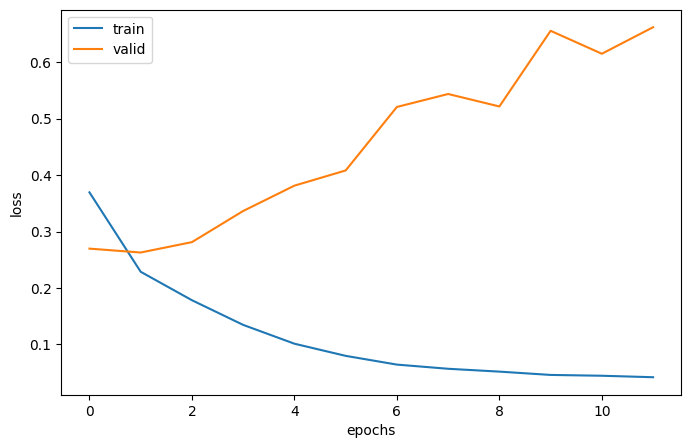

In [42]:
lstm_cnn.compile(loss='binary_crossentropy', optimizer='adam',
             metrics=['accuracy', tf.keras.metrics.AUC(name='auc')])
early_stop = EarlyStopping(patience=10, restore_best_weights=True)
model_path = "./model/bank_app_review_lstm_cnn.keras"
checkpoint = ModelCheckpoint(filepath=model_path, monitor='val_loss',
                            save_best_only=True,
                            verbose=1)
lstm_cnn_history = lstm_cnn.fit(X_train, y_train, epochs=1000, batch_size=64,
                         validation_data=(X_valid, y_valid),
                         callbacks=[early_stop, checkpoint])
plt.figure(figsize=(8, 5))
plt.plot(lstm_cnn_history.history['loss'])
plt.plot(lstm_cnn_history.history['val_loss'])
plt.xlabel('epochs')
plt.ylabel('loss')
plt.legend(['train', 'valid'])
plt.show()

In [43]:
print(lstm_cnn.evaluate(X_valid, y_valid))

209/209 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.9014 - auc: 0.9576 - loss: 0.2564
[0.2627829611301422, 0.8951153755187988, 0.9554592967033386]


In [44]:
pred = lstm_cnn.predict(X_valid)
pred

209/209 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step


array([[0.98102784],
       [0.98603904],
       [0.02488011],
       ...,
       [0.9686122 ],
       [0.14116783],
       [0.9751012 ]], dtype=float32)

In [45]:
pred.shape

(6674, 1)

In [46]:
pred = pd.DataFrame(pred)

In [47]:
y_valid = pd.DataFrame(y_valid.reset_index(drop=True))
y_valid

,is_good
0,1
1,1
2,0
3,1
4,0
...,...
6669,0
6670,1
6671,1
6672,0


In [48]:
result = pd.concat([y_valid, pred], axis=1)
result

,is_good,0
0,1,0.981028
1,1,0.986039
2,0,0.024880
3,1,0.982489
4,0,0.039691
...,...,...
6669,0,0.033973
6670,1,0.973512
6671,1,0.968612
6672,0,0.141168


In [49]:
result.columns = ['is_good', 'pred']
result

,is_good,pred
0,1,0.981028
1,1,0.986039
2,0,0.024880
3,1,0.982489
4,0,0.039691
...,...,...
6669,0,0.033973
6670,1,0.973512
6671,1,0.968612
6672,0,0.141168


In [50]:
result['pred'] = result['pred'].apply(lambda x: 1 if x > 0.5 else 0)

In [51]:
from sklearn.metrics import classification_report
print(classification_report(result['is_good'], result['pred']))

              precision    recall  f1-score   support

           0       0.84      0.92      0.88      2702
           1       0.94      0.88      0.91      3972

    accuracy                           0.90      6674
   macro avg       0.89      0.90      0.89      6674
weighted avg       0.90      0.90      0.90      6674



# Attention => GPT
* RNN이나 LSTM은 전체 문장을 기억
* 중요한 단어에만 집중

In [53]:
# !pip install attention

In [23]:
from attention import Attention

In [30]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling1D, LayerNormalization, MultiHeadAttention, Add

In [31]:
inputs = Input(shape=(max_length,))
x = Embedding(input_dim=word_size, output_dim=128)(inputs)
x = Dropout(0.3)(x)
# 양방향 LSTM
x = Bidirectional(LSTM(128, return_sequences=True))(x)
# 멀티헤드 어텐션
attn_output = MultiHeadAttention(num_heads=4, key_dim=64)(x, x)
attn_output = Dropout(0.3)(attn_output)
x = Add()([x, attn_output])
x = LayerNormalization()(x)
x = GlobalAveragePooling1D()(x)
# DNN
x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)
x = Dense(64, activation='relu')(x)
x = Dense(32, activation='relu')(x)
# 출력층
outputs = Dense(1, activation='sigmoid')(x)
attn_model = Model(inputs=inputs, outputs=outputs)
attn_model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 302)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_2         │ (None, 302, 128)  │  1,665,280 │ input_layer_2[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_5 (Dropout) │ (None, 302, 128)  │          0 │ embedding_2[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_1     │ (None, 302, 256)  │    263,168 │ dropout_5[0][0]   │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 302, 256)  │    263,168 │ bidirectional_1[… │
│ (MultiHeadAttentio… │                   │            │ bidirectional_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_7 (Dropout) │ (None, 302, 256)  │          0 │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 302, 256)  │          0 │ bidirectional_1[… │
│                     │                   │            │ dropout_7[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 302, 256)  │        512 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 256)       │          0 │ layer_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 128)       │     32,896 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_8 (Dropout) │ (None, 128)       │          0 │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 64)        │      8,256 │ dropout_8[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 32)        │      2,080 │ dense_5[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 1)         │         33 │ dense_6[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,235,393 (8.53 MB)

 Trainable params: 2,235,393 (8.53 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/2000
122/122 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step - accuracy: 0.5919 - auc: 0.5793 - loss: 0.6758
Epoch 1: val_loss improved from inf to 0.47765, saving model to ./model/bank_app_review_attn_model.keras
122/122 ━━━━━━━━━━━━━━━━━━━━ 19s 135ms/step - accuracy: 0.5924 - auc: 0.5801 - loss: 0.6755 - val_accuracy: 0.8052 - val_auc: 0.8626 - val_loss: 0.4777
Epoch 2/2000
122/122 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step - accuracy: 0.8237 - auc: 0.8475 - loss: 0.4411
Epoch 2: val_loss improved from 0.47765 to 0.34576, saving model to ./model/bank_app_review_attn_model.keras
122/122 ━━━━━━━━━━━━━━━━━━━━ 16s 130ms/step - accuracy: 0.8238 - auc: 0.8477 - loss: 0.4408 - val_accuracy: 0.8695 - val_auc: 0.9377 - val_loss: 0.3458
Epoch 3/2000
122/122 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step - accuracy: 0.8823 - auc: 0.9245 - loss: 0.3259
Epoch 3: val_loss improved from 0.34576 to 0.30957, saving model to ./model/bank_app_review_attn_model.keras
122/122 ━━━━━━━━━━━━━━━━━━━━ 19s 156ms/step - accuracy: 0.882

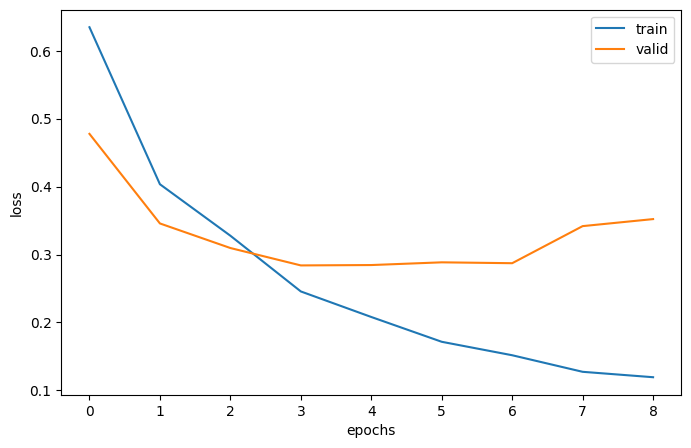

In [32]:
attn_model.compile(loss='binary_crossentropy', optimizer='adam',
             metrics=['accuracy', tf.keras.metrics.AUC(name='auc')])
early_stop = EarlyStopping(patience=5, restore_best_weights=True)
model_path = "./model/bank_app_review_attn_model.keras"
checkpoint = ModelCheckpoint(filepath=model_path, monitor='val_loss',
                            save_best_only=True,
                            verbose=1)
attn_model_history = attn_model.fit(X_train, y_train, epochs=2000, batch_size=128,
                         validation_data=(X_valid, y_valid),
                         callbacks=[early_stop, checkpoint])
plt.figure(figsize=(8, 5))
plt.plot(attn_model_history.history['loss'])
plt.plot(attn_model_history.history['val_loss'])
plt.xlabel('epochs')
plt.ylabel('loss')
plt.legend(['train', 'valid'])
plt.show()

In [33]:
print(attn_model.evaluate(X_valid, y_valid))

209/209 ━━━━━━━━━━━━━━━━━━━━ 7s 30ms/step - accuracy: 0.8978 - auc: 0.9543 - loss: 0.2750
[0.2839586138725281, 0.8957147002220154, 0.9522128701210022]


In [34]:
pred = attn_model.predict(X_valid)
pred

209/209 ━━━━━━━━━━━━━━━━━━━━ 5s 24ms/step


array([[0.9740209 ],
       [0.98424107],
       [0.00869013],
       ...,
       [0.92314553],
       [0.01708643],
       [0.98096335]], dtype=float32)

In [35]:
pred.shape

(6674, 1)

In [36]:
pred = pd.DataFrame(pred)

In [37]:
y_valid = pd.DataFrame(y_valid.reset_index(drop=True))
y_valid

,is_good
0,1
1,1
2,0
3,1
4,0
...,...
6669,0
6670,1
6671,1
6672,0


In [38]:
result = pd.concat([y_valid, pred], axis=1)
result

,is_good,0
0,1,0.974021
1,1,0.984241
2,0,0.008690
3,1,0.988155
4,0,0.009237
...,...,...
6669,0,0.007174
6670,1,0.947391
6671,1,0.923146
6672,0,0.017086


In [39]:
result.columns = ['is_good', 'pred']
result

,is_good,pred
0,1,0.974021
1,1,0.984241
2,0,0.008690
3,1,0.988155
4,0,0.009237
...,...,...
6669,0,0.007174
6670,1,0.947391
6671,1,0.923146
6672,0,0.017086


In [40]:
result['pred'] = result['pred'].apply(lambda x: 1 if x > 0.5 else 0)

In [41]:
from sklearn.metrics import classification_report
print(classification_report(result['is_good'], result['pred']))

              precision    recall  f1-score   support

           0       0.85      0.89      0.87      2702
           1       0.93      0.90      0.91      3972

    accuracy                           0.90      6674
   macro avg       0.89      0.90      0.89      6674
weighted avg       0.90      0.90      0.90      6674

